In [11]:
from networkSim.utils.netStat import net_episode_generator
import matplotlib.pyplot as plt

In [12]:
datas = []
for i,item in enumerate(net_episode_generator(episode_length= 120)):
    datas.append(item)
    if i == 50:
        break

In [13]:
total_duration = sum(item.duration for item in datas)
print(total_duration)

2069.8814005870536


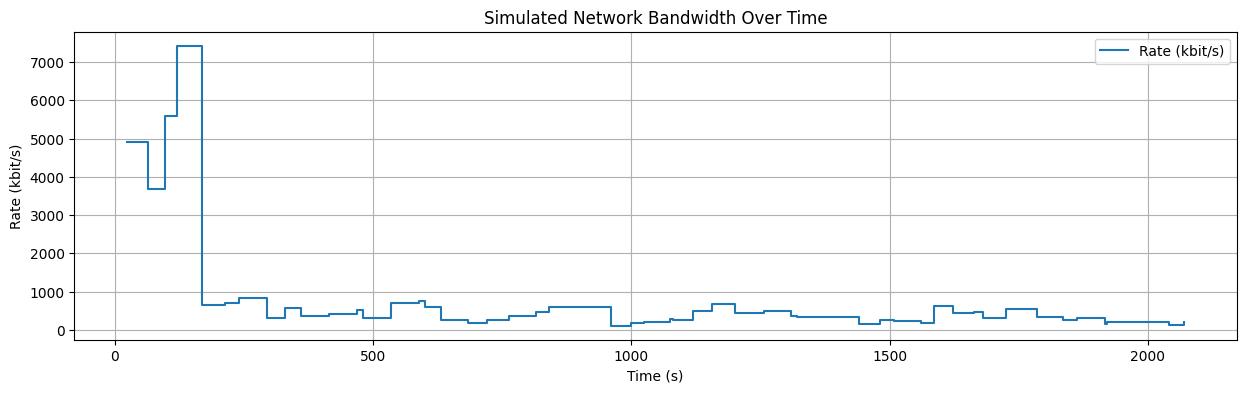

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# 1️⃣ Prepare time series
times = [0]  # cumulative time
rates = [datas[0].rate]
states = []  # store resolution for color coding



for item in datas:
    states.append(item.state)
    # append next cumulative time
    times.append(times[-1] + item.duration)
    rates.append(item.rate)

# remove first dummy entry
times = times[1:]
rates = rates[1:]

# 2️⃣ Plot rate over time
plt.figure(figsize=(15,4))
plt.step(times, rates, where='post', label="Rate (kbit/s)")
plt.xlabel("Time (s)")
plt.ylabel("Rate (kbit/s)")
plt.title("Simulated Network Bandwidth Over Time")
plt.grid(True)
plt.legend()
plt.show()

# 3️⃣ Optional: color by state
state_colors = {
    "720p": "green",
    "480p": "lime",
    "360p": "yellow",
    "240p": "orange",
    "144p": "red",
    "stall": "black"
}


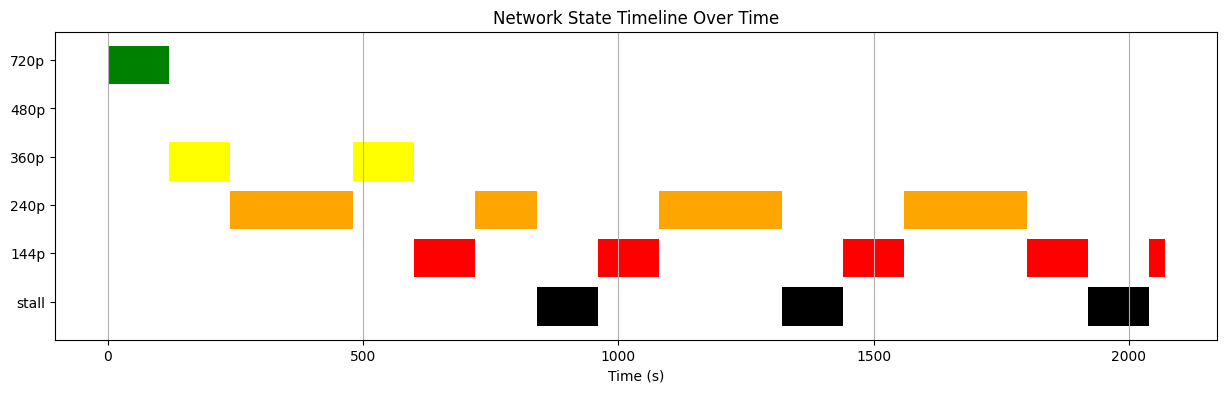

In [15]:
import matplotlib.pyplot as plt

# Map states to colors
state_colors = {
    "720": "green",
    "480": "lime",
    "360": "yellow",
    "240": "orange",
    "144": "red",
    "stall": "black"
}

# Prepare data for broken_barh
bars = []
state_y = {
    "720": 50,
    "480": 40,
    "360": 30,
    "240": 20,
    "144": 10,
    "stall": 0
}

cumulative_time = 0
for item in datas:
    state = item.state
    bars.append(
        (cumulative_time, item.duration, state)
    )
    cumulative_time += item.duration

# Plot
plt.figure(figsize=(15,4))
for start, duration, state in bars:
    plt.broken_barh(
        [(start, duration)],  # x = (start, width)
        (state_y[state], 8),  # y = (bottom, height)
        facecolors=state_colors[state]
    )

plt.yticks([5, 15, 25, 35, 45, 55], ["stall","144p","240p","360p","480p","720p"])
plt.xlabel("Time (s)")
plt.title("Network State Timeline Over Time")
plt.grid(True, axis='x')
plt.show()